**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [2663]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

In [2664]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [2665]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana6"
os.chdir(DIR)
compu_df = pd.read_csv('computer_prices.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2666]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

texto: 12 y númericas: 15

In [2667]:
compu_df.nunique()

,0
device_type,2
brand,10
model,99036
release_year,8
os,4
form_factor,10
cpu_brand,3
cpu_model,26971
cpu_tier,6
cpu_cores,12


In [2668]:
compu_df.head(3)

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99


In [2669]:
compu_df.drop(columns = ['model', 'cpu_model'], inplace = True)
compu_df.head(3)

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99


2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [2670]:
compu_df.duplicated().sum()

np.int64(0)

In [2671]:
compu_df.isna().sum()

,0
device_type,0
brand,0
release_year,0
os,0
form_factor,0
cpu_brand,0
cpu_tier,0
cpu_cores,0
cpu_threads,0
gpu_brand,0


In [2672]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   release_year         100000 non-null  int64  
 3   os                   100000 non-null  object 
 4   form_factor          100000 non-null  object 
 5   cpu_brand            100000 non-null  object 
 6   cpu_tier             100000 non-null  int64  
 7   cpu_cores            100000 non-null  int64  
 8   cpu_threads          100000 non-null  int64  
 9   gpu_brand            100000 non-null  object 
 10  gpu_model            100000 non-null  object 
 11  gpu_tier             100000 non-null  int64  
 12  vram_gb              100000 non-null  int64  
 13  ram_gb               100000 non-null  int64  
 14  storage_type         100000 non-null  object 
 15  storage_gb        

In [2673]:
compu_df['bluetooth'].value_counts()

,count
bluetooth,
5.2,28065
5.0,25980
5.1,21951
5.3,18065
4.2,5939


In [2674]:
num_cols = compu_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
cat_cols = compu_df.select_dtypes(include = ['object', 'category']).columns.tolist()

In [2675]:
pd.concat([compu_df[num_cols].describe().T, compu_df[num_cols].kurt().rename('curtosis'), compu_df[num_cols].skew().rename('simetria')], axis=1)

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
release_year,100000.0,2022.320850,2.025761,2018.00,2021.00,2023.00,2024.00,2025.00,-0.715846,-0.479062
cpu_tier,100000.0,3.153490,1.373175,1.00,2.00,3.00,4.00,6.00,-0.751699,0.174307
cpu_cores,100000.0,10.515740,5.044092,4.00,6.00,8.00,14.00,28.00,1.007646,1.087762
cpu_threads,100000.0,19.372700,9.718426,4.00,12.00,16.00,24.00,56.00,1.300012,1.125744
gpu_tier,100000.0,2.991350,1.459643,1.00,2.00,3.00,4.00,6.00,-0.851269,0.285752
vram_gb,100000.0,6.152180,3.964926,0.00,4.00,6.00,8.00,16.00,-0.354864,0.281362
ram_gb,100000.0,39.706400,31.902684,8.00,16.00,32.00,64.00,144.00,0.195870,1.049278
storage_gb,100000.0,903.936000,774.243654,256.00,512.00,512.00,1024.00,4096.00,6.272154,2.304037
storage_drive_count,100000.0,1.524980,0.797284,1.00,1.00,1.00,2.00,4.00,1.746179,1.540038
charger_watts,100000.0,61.383450,62.795034,0.00,0.00,65.00,90.00,240.00,0.238015,0.855735


In [2676]:
compu_df[cat_cols].describe(include = ['object', 'category']).T

,count,unique,top,freq
device_type,100000,2,Laptop,59844
brand,100000,10,Lenovo,15992
os,100000,4,Windows,71817
form_factor,100000,10,Mainstream,17819
cpu_brand,100000,3,Intel,52774
gpu_brand,100000,4,NVIDIA,54712
gpu_model,100000,49,Apple Integrated,18922
storage_type,100000,4,NVMe,45059
display_type,100000,6,LED,32000
wifi,100000,4,Wi-Fi 6,46149


In [2677]:
for column in cat_cols:
    print(compu_df[column].value_counts())
    print('-' * 50)

device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64
--------------------------------------------------
brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64
--------------------------------------------------
os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64
--------------------------------------------------
form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64
--------------------------------------------------
cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64
--------------------------------------------------
gpu_brand
NVIDIA    54712
Apple

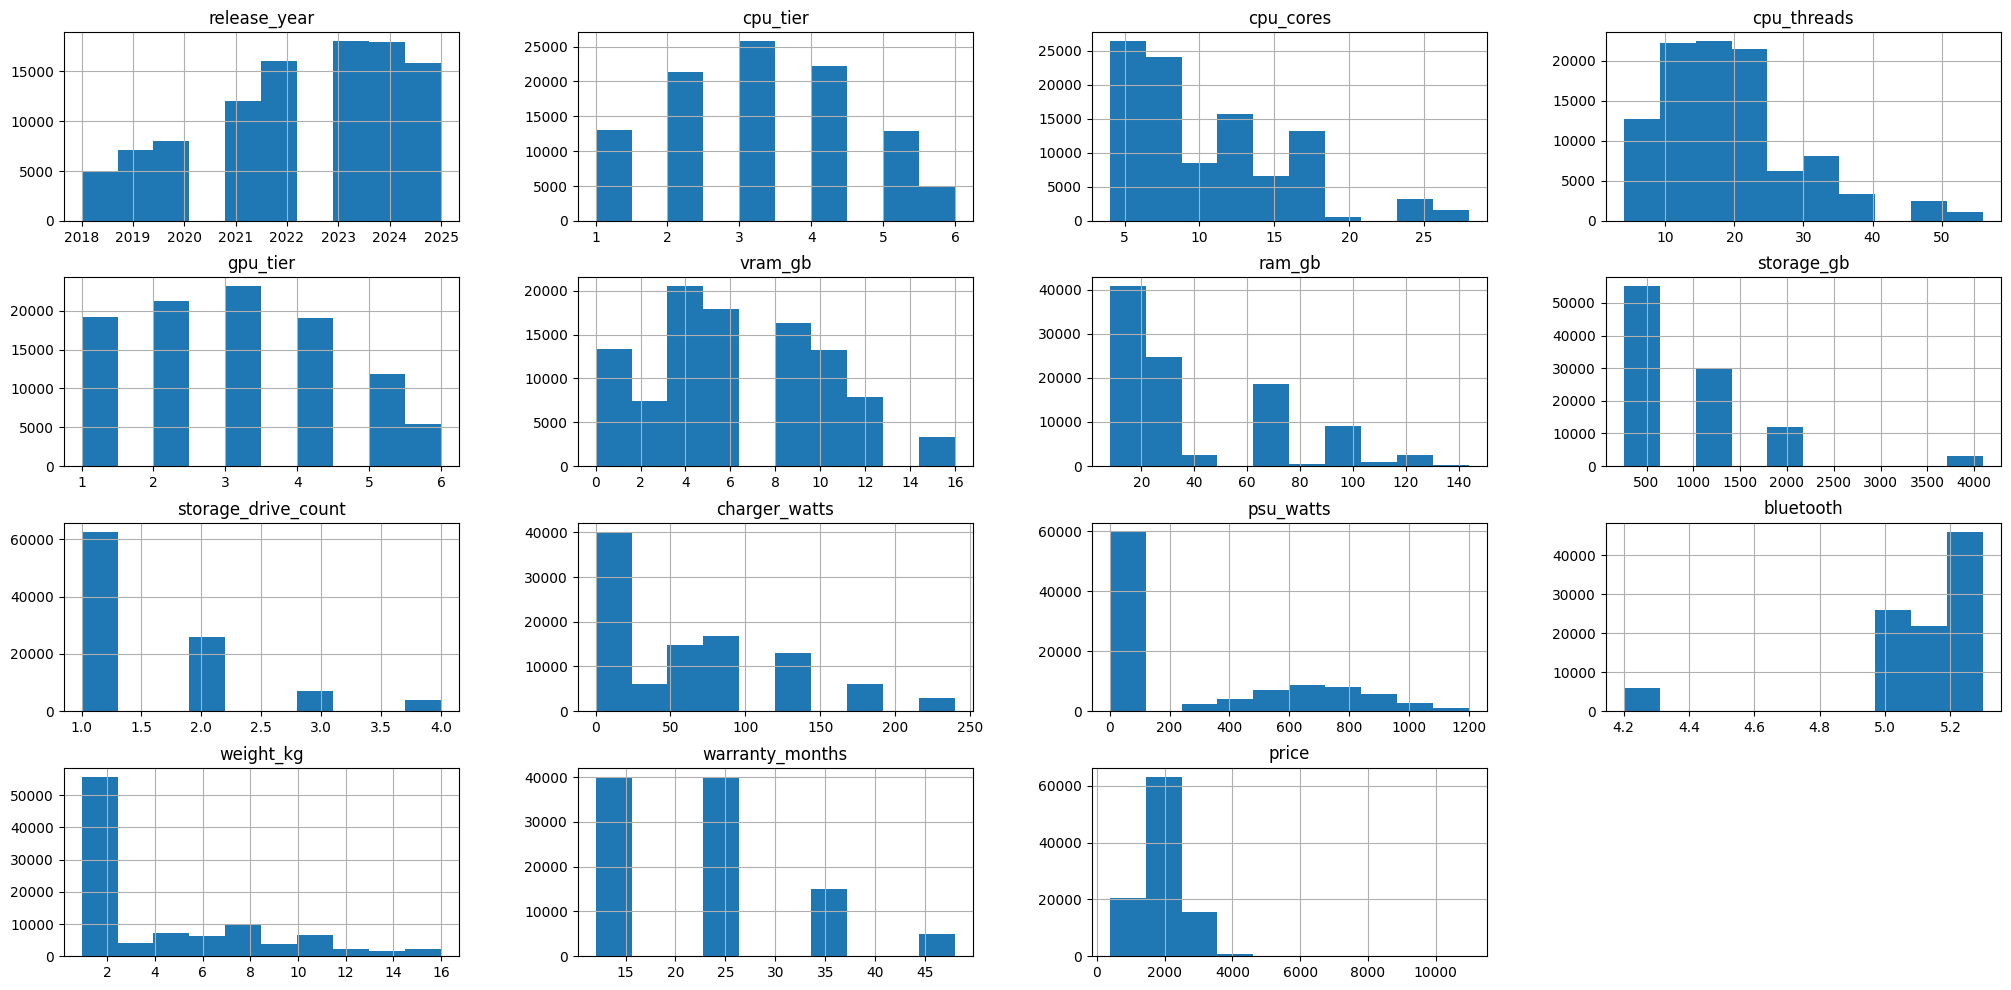

In [2678]:
#histogramas variables numericas
compu_df[num_cols].hist(figsize=(25,12))
plt.show()

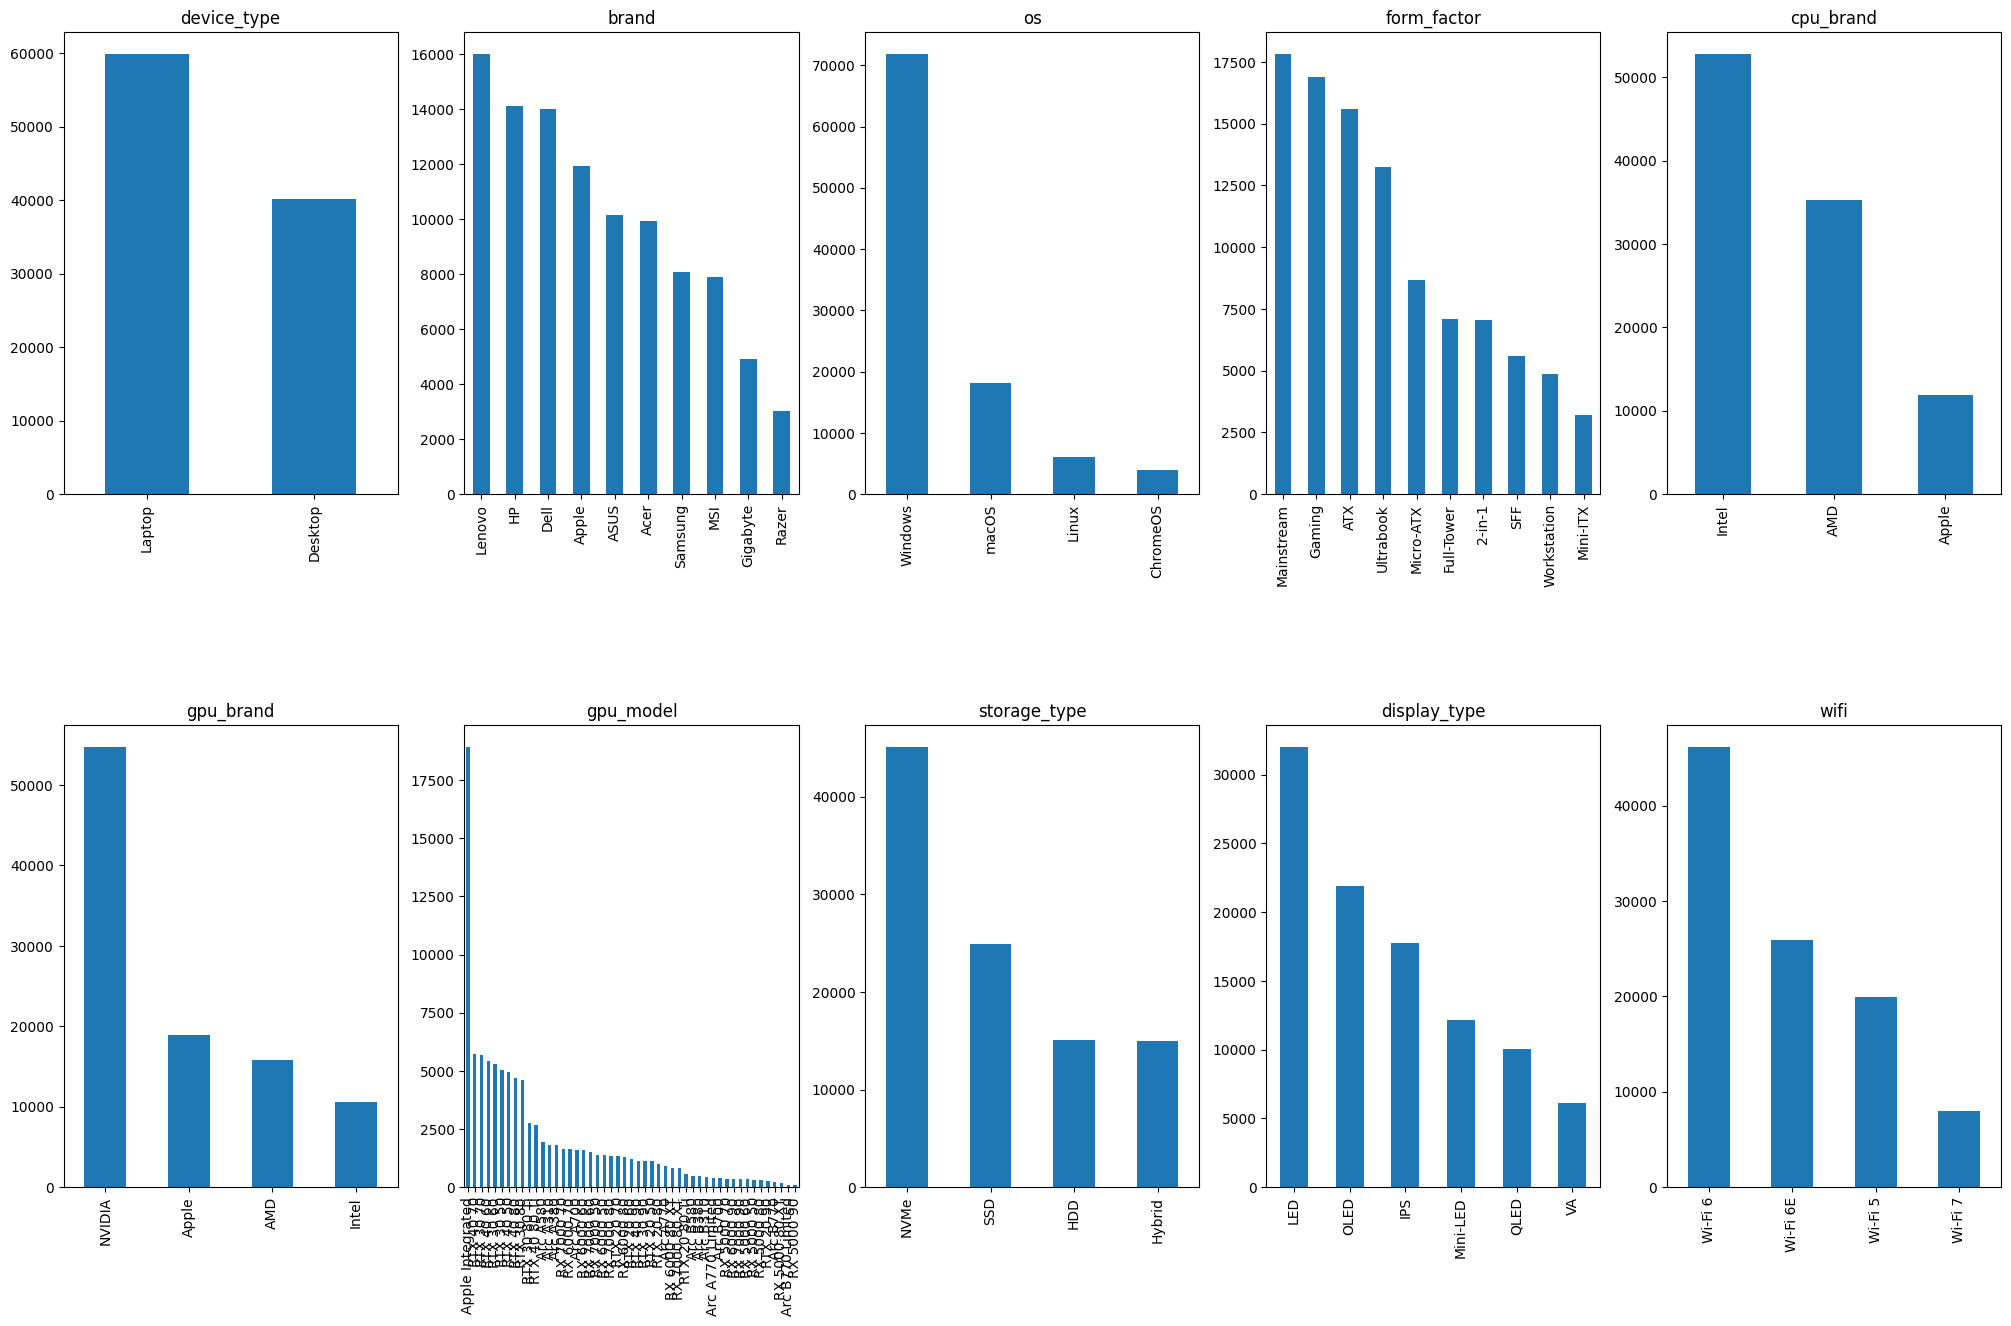

In [2679]:
#graficar todas las variables, seleccionar alta cardinalidad para grafica aparte
fig, axes = plt.subplots(2,5, figsize=(25,15))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for col, ax in zip(compu_df[cat_cols], axes):
  compu_df[col].value_counts().plot(kind='bar', ax=ax)
  ax.set(title=f'{col}', xlabel=None)

<BarContainer object of 10 artists>

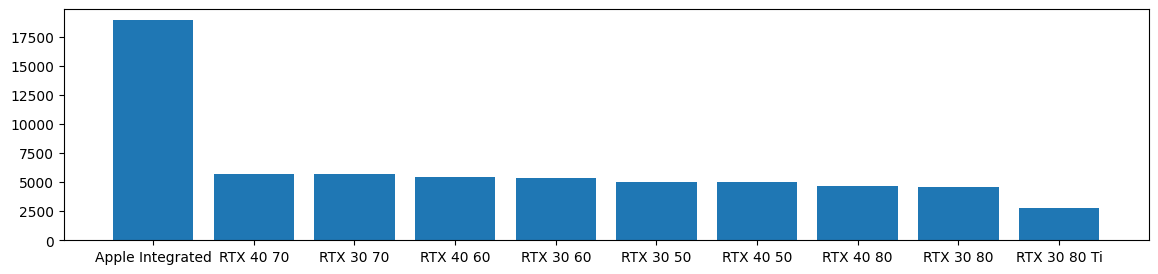

In [2680]:
counts = compu_df['gpu_model'].value_counts()
top_10 = counts.head(10)
fig, axes = plt.subplots(1,1, figsize=(14,3))
plt.bar(top_10.index.astype(str), top_10.values)

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

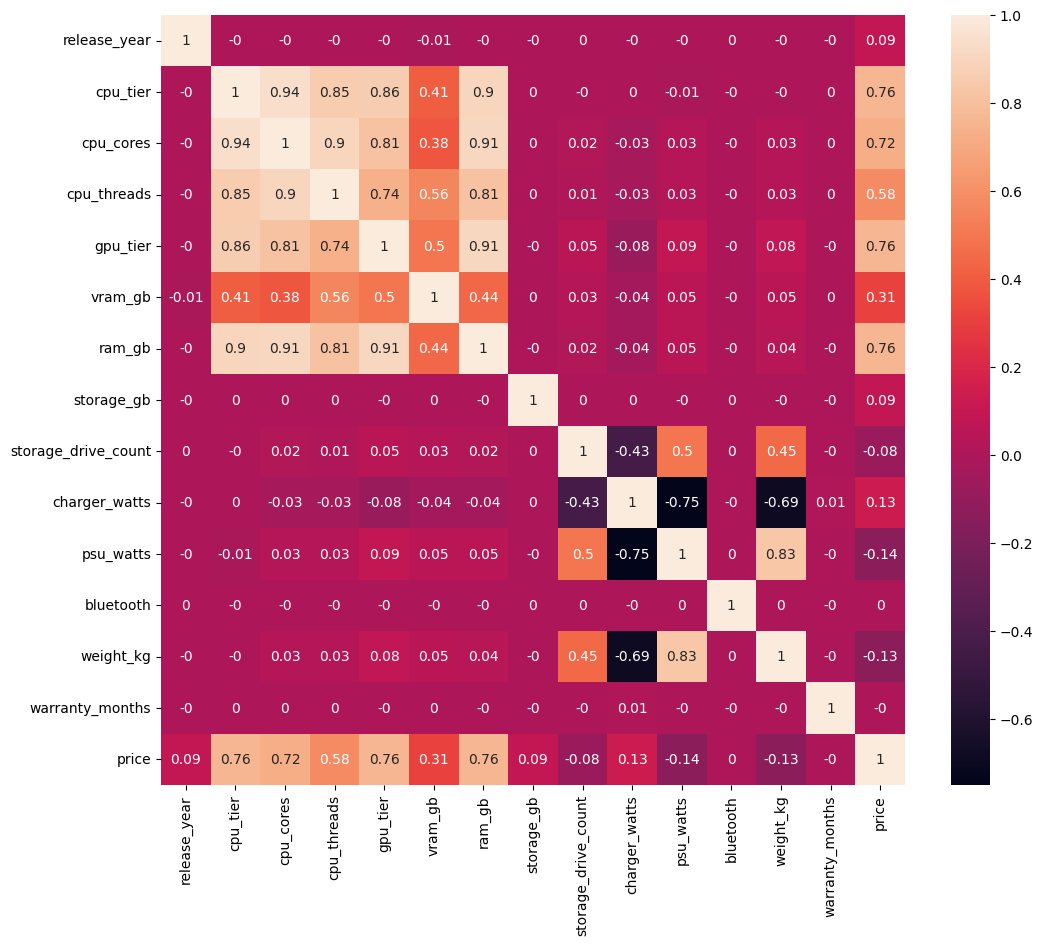

In [2681]:
plt.figure(figsize = (12, 10))
sns.heatmap(round(compu_df.corr(numeric_only=True),2), annot = True)
plt.show()

In [2682]:
corr = round(compu_df.corr(numeric_only=True), 2)
corr_variables = corr[(corr > 0.9) & (corr < 1.0)].dropna(how='all', axis=0).dropna(how='all', axis=1)
corr_variables

,cpu_tier,cpu_cores,gpu_tier,ram_gb
cpu_tier,NaN,0.94,NaN,NaN
cpu_cores,0.94,NaN,NaN,0.91
gpu_tier,NaN,NaN,NaN,0.91
ram_gb,NaN,0.91,0.91,NaN


In [2683]:
compu_df.drop(columns = ['cpu_cores', 'gpu_tier'], inplace = True)

se eliminan:
* 'gpu_tires': correlacion demasiado alta (0.91) con 'ram_gb'
* 'cpu_cores':correlacion alta (0.94 y 0.91) con 'cpu_tires' y 'ram_gb'

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [2684]:
compu_trans = compu_df
compu_trans['years_since_release'] = date.today().year - compu_trans['release_year']
compu_trans.drop(columns = ['release_year'], inplace = True)

In [2685]:
compu_trans['years_since_release'].value_counts()

,count
years_since_release,
2,18020
1,17969
3,16054
0,15835
4,12016
5,7986
6,7090
7,5030


In [2686]:
compu_trans['vram_gb'].value_counts()

,count
vram_gb,
4,20517
6,17930
8,16382
0,13389
10,13251
12,7835
2,7368
16,3328


In [2687]:
grouper = KBinsDiscretizer(n_bins= 4, encode='ordinal', strategy='quantile')
compu_trans[['vram_gb']] = grouper.fit_transform(compu_trans[['vram_gb']])

In [2688]:
compu_trans['vram_gb'].value_counts()

,count
vram_gb,
3.0,40796
0.0,20757
1.0,20517
2.0,17930


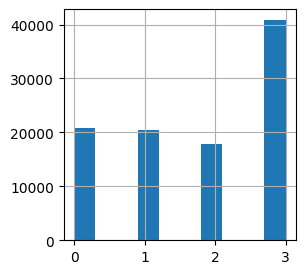

In [2689]:
#histograma
compu_trans['vram_gb'].hist(figsize=(3,3))
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [2690]:
print(compu_trans['charger_watts'].value_counts())
print('\n' + '-'* 50)
print(compu_trans['psu_watts'].value_counts())

charger_watts
0      40156
90     16749
65     14892
120    13056
180     6089
45      6019
240     3039
Name: count, dtype: int64

--------------------------------------------------
psu_watts
0       59844
650      8831
750      7923
550      7179
850      5625
450      4149
1000     2818
300      2447
1200     1184
Name: count, dtype: int64


In [2691]:
compu_trans['power_watts'] = (np.where (compu_trans['charger_watts'] == 0, compu_trans['psu_watts'], compu_trans['charger_watts']))

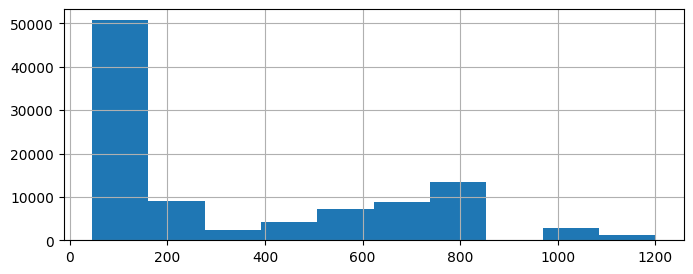

In [2692]:
compu_trans['power_watts'].hist(figsize=(8,3))
plt.show()

In [2693]:
compu_trans.drop(columns = ['charger_watts', 'psu_watts'], inplace = True)

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [2694]:
#Logarítmica
transformer = FunctionTransformer(func=np.log)
log_price = transformer.fit_transform(compu_trans[['price']])

In [2695]:
#Raíz cuadrada
transformer = FunctionTransformer(func=np.sqrt)
raiz_price = transformer.fit_transform(compu_trans[['price']])

In [2696]:
#Box - cox
transformer = PowerTransformer(method='box-cox', standardize=False)
bc_price = transformer.fit_transform(compu_trans[['price']])

In [2697]:
transformaciones = pd.DataFrame({
    'Price': compu_trans['price'],
    'Logaritmo': log_price.values.ravel(),
    'Raiz_Cuadrada': raiz_price.values.ravel(),
    'Box_Cox': bc_price.ravel()
})
transformaciones.head(3)

,Price,Logaritmo,Raiz_Cuadrada,Box_Cox
0,1383.99,7.232726,37.202016,13.084409
1,2274.99,7.729731,47.696855,14.616126
2,1879.99,7.539022,43.358851,14.014803


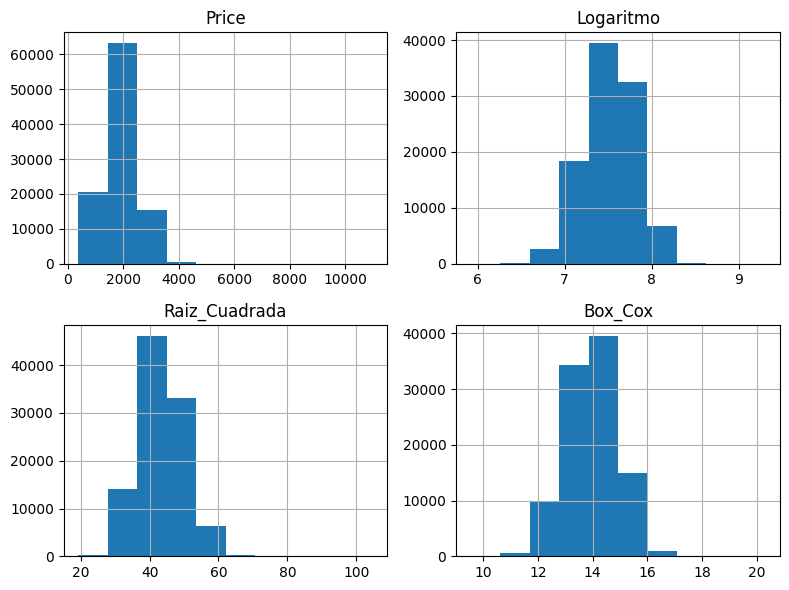

In [2698]:
transformaciones.hist(figsize=(8, 6))
plt.tight_layout()
plt.show()

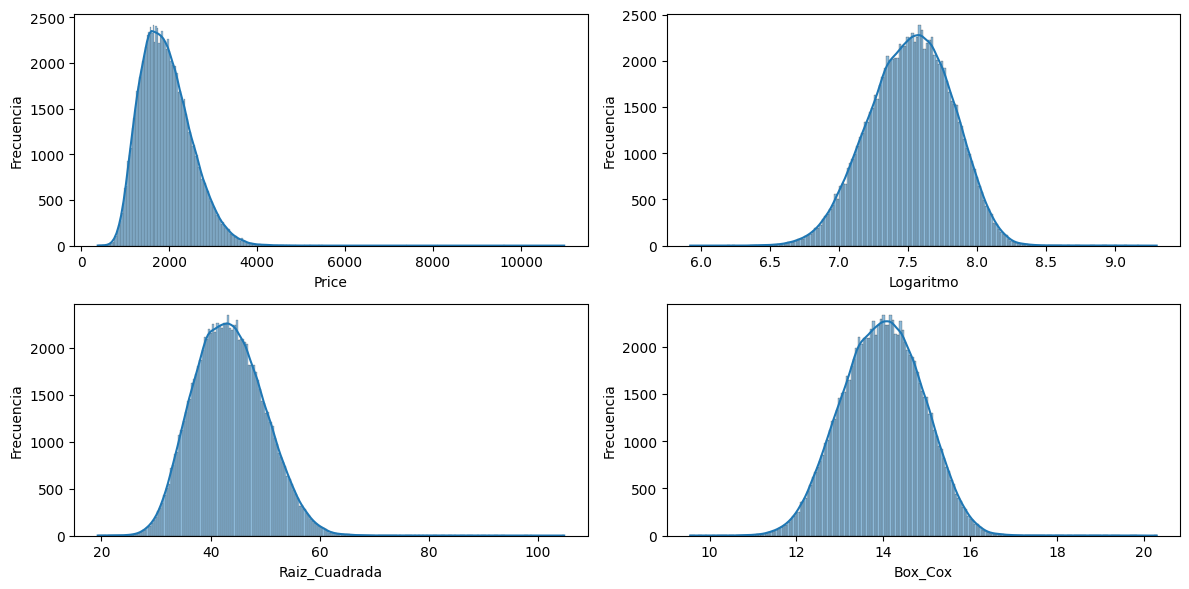

In [2699]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.ravel()
for col, ax in zip(transformaciones.columns, axes):
    sns.histplot(data=transformaciones, x=col, kde=True, ax=ax)
    ax.set(xlabel=col, ylabel='Frecuencia')
plt.tight_layout()
plt.show()

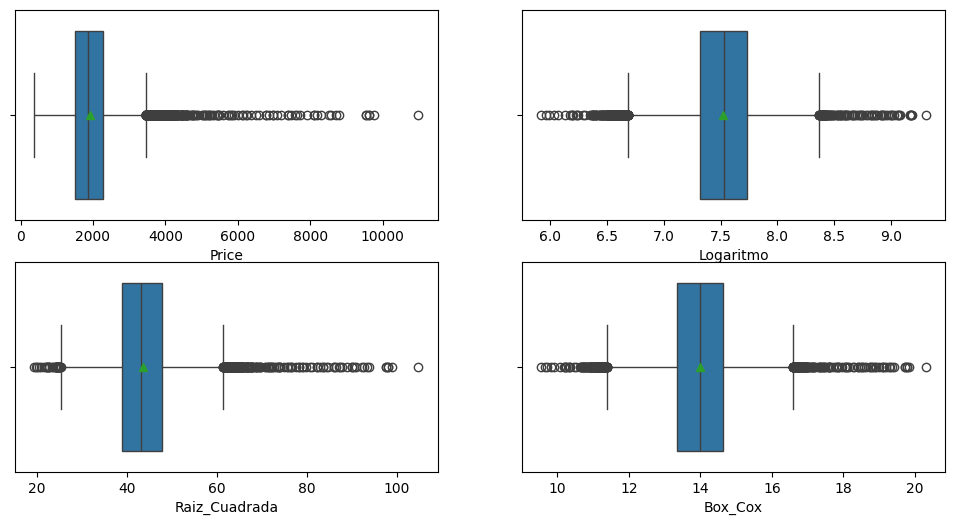

In [2700]:
#boxplot para las variables
fig, axes = plt.subplots(2,2, figsize=(12, 6))
axes = axes.ravel()
for col, ax in zip(transformaciones.columns, axes):
  sns.boxplot(x=transformaciones[col], ax=ax, showmeans=True)
  ax.set(xlabel=f'{col}')

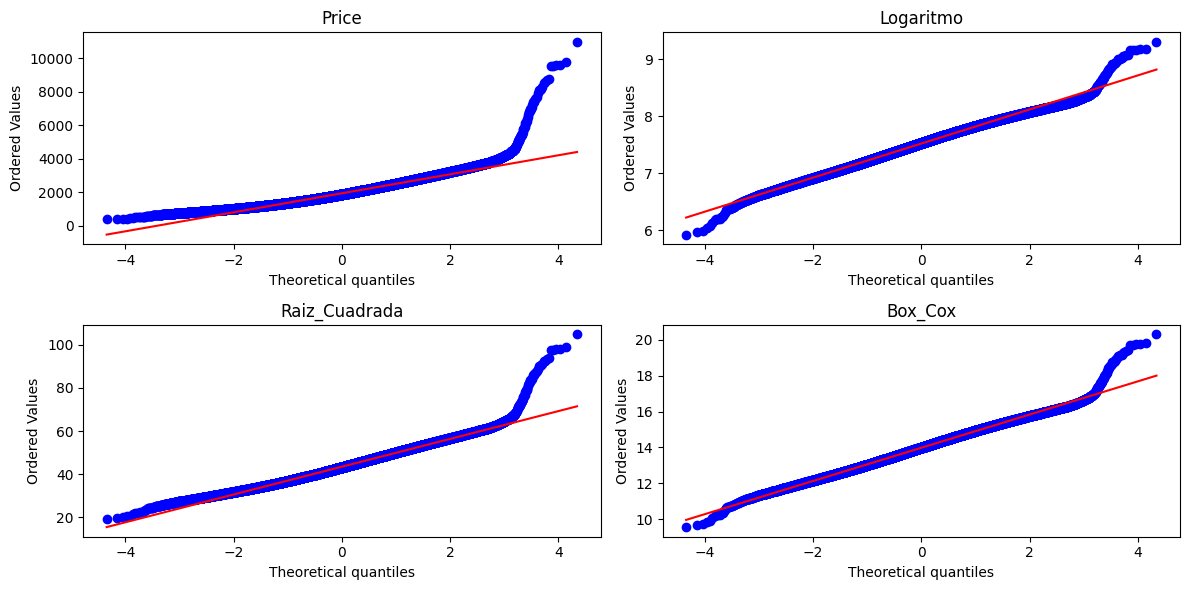

In [2701]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.ravel()
for col, ax in zip(transformaciones.columns, axes):
    stats.probplot(transformaciones[col], dist="norm", plot=ax)
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

In [2702]:
transformaciones.skew()

,0
Price,0.986644
Logaritmo,-0.133105
Raiz_Cuadrada,0.332253
Box_Cox,-0.000238


In [2703]:
for col in transformaciones.columns:
    Q1 = transformaciones[col].quantile(0.25)
    Q3 = transformaciones[col].quantile(0.75)
    IQR = Q3 - Q1
    BM = (transformaciones[col] > (Q3 + 1.5 * IQR)) | (transformaciones[col] < (Q1 - 1.5 * IQR))
    print(f"{col}: {BM.sum()}")

Price: 976
Logaritmo: 386
Raiz_Cuadrada: 364
Box_Cox: 317


Se selecciona la transformacion box-cox, por las siguientes razones:
* el skew indica una curva casi simetrica
* contiene la menor cantidad de outliers
* media coincide casi a la perfeccion con mediana (boxplot)
* q-q plot, los mayoria de los datos siguen la curva de referencia

In [2704]:
#Box - cox para las 3 variables
transformer = PowerTransformer(method='box-cox', standardize=False)
compu_trans['price'] = transformer.fit_transform(compu_trans[['price']])

In [2705]:
transformer = PowerTransformer(method='box-cox', standardize=False)
compu_trans['weight_kg'] = transformer.fit_transform(compu_trans[['weight_kg']])

In [2706]:
transformer = PowerTransformer(method='box-cox', standardize=False)
compu_trans['power_watts'] = transformer.fit_transform(compu_trans[['power_watts']])

In [2707]:
compu_trans.head(5)

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,vram_gb,...,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,3,24,NVIDIA,RTX 40 60,2.0,...,1024,1,LED,Wi-Fi 6,5.1,1.423738,36,13.084409,3,4.027280
1,Laptop,Samsung,Windows,Mainstream,Intel,4,24,NVIDIA,RTX 40 80,3.0,...,512,1,OLED,Wi-Fi 6,5.3,0.600182,12,14.616126,3,3.309631
2,Desktop,Lenovo,macOS,SFF,AMD,2,16,NVIDIA,RTX 40 50,1.0,...,512,2,LED,Wi-Fi 6,5.0,1.264217,24,14.014803,1,4.068825
3,Desktop,Dell,Windows,ATX,AMD,2,12,AMD,RX 7000 60,2.0,...,512,2,IPS,Wi-Fi 6,5.2,1.201393,36,12.971066,1,3.978717
4,Laptop,Gigabyte,Linux,Gaming,AMD,5,32,NVIDIA,RTX 30 80 Ti,3.0,...,256,1,Mini-LED,Wi-Fi 6,5.2,0.368418,12,15.149121,1,3.175932


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [2708]:
num_cols = compu_trans.select_dtypes(include = ['int64', 'float64']).columns.tolist()
num_cols

['cpu_tier',
 'cpu_threads',
 'vram_gb',
 'ram_gb',
 'storage_gb',
 'storage_drive_count',
 'bluetooth',
 'weight_kg',
 'warranty_months',
 'price',
 'years_since_release',
 'power_watts']

In [2709]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(compu_trans[num_cols])
compu_trans[num_cols] = scaled_data
compu_trans.head(3)


,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,vram_gb,...,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.666667,...,0.200000,0.000000,LED,Wi-Fi 6,0.818182,0.932995,0.666667,0.328669,0.428571,0.887860
1,Laptop,Samsung,Windows,Mainstream,Intel,0.6,0.384615,NVIDIA,RTX 40 80,1.000000,...,0.066667,0.000000,OLED,Wi-Fi 6,1.000000,0.423737,0.000000,0.471202,0.428571,0.357238
2,Desktop,Lenovo,macOS,SFF,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.333333,...,0.066667,0.333333,LED,Wi-Fi 6,0.727273,0.834353,0.333333,0.415246,0.142857,0.918578


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [2710]:
encoder = OrdinalEncoder(categories=[['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']])
encoded_data = encoder.fit_transform(compu_trans[['wifi']])
compu_trans['wifi'] = encoded_data
compu_trans['wifi'].value_counts()

,count
wifi,
1.0,46149
2.0,25923
0.0,19926
3.0,8002


In [2711]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(compu_trans[['wifi']])
compu_trans['wifi'] = scaled_data
compu_trans['wifi'].value_counts()

,count
wifi,
0.333333,46149
0.666667,25923
0.000000,19926
1.000000,8002


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [2712]:
encoder = BinaryEncoder()
bin_df = encoder.fit_transform(compu_trans[['gpu_model']])
bin_df.head(3)

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [2713]:
cat_cols = compu_trans.select_dtypes(include = ['object', 'category']).columns.tolist()
cat_cols.remove('gpu_model')
cat_cols

['device_type',
 'brand',
 'os',
 'form_factor',
 'cpu_brand',
 'gpu_brand',
 'storage_type',
 'display_type']

In [2714]:
encoder = OneHotEncoder(drop='first')
ohe = encoder.fit_transform(compu_trans[cat_cols])
ohe_df = pd.DataFrame(ohe.toarray(), columns=encoder.get_feature_names_out(cat_cols))
ohe_df.head(3)

,device_type_Laptop,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_Lenovo,brand_MSI,brand_Razer,brand_Samsung,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [2715]:
#concatenar df con compu_trans
compu_trans= pd.concat([compu_trans, bin_df, ohe_df], axis=1)
compu_trans.head(3)

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,vram_gb,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,Desktop,Samsung,Windows,ATX,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.666667,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Laptop,Samsung,Windows,Mainstream,Intel,0.6,0.384615,NVIDIA,RTX 40 80,1.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Desktop,Lenovo,macOS,SFF,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.333333,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [2716]:
print(cat_cols)
print(num_cols)

['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type']
['cpu_tier', 'cpu_threads', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'bluetooth', 'weight_kg', 'warranty_months', 'price', 'years_since_release', 'power_watts']


In [2717]:
compu_trans.drop(columns = cat_cols, inplace = True)
compu_trans.drop(columns = num_cols, inplace = True)
compu_trans.drop(columns = ['gpu_model'], inplace = True)
compu_trans.head(3)

,wifi,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5,device_type_Laptop,brand_Acer,brand_Apple,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,0.333333,0,0,0,0,0,1,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.333333,0,0,0,0,1,0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.333333,0,0,0,0,1,1,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [2718]:
compu_trans.describe().T

,count,mean,std,min,25%,50%,75%,max
wifi,100000.0,0.40667,0.284834,0.0,0.333333,0.333333,0.666667,1.0
gpu_model_0,100000.0,0.11816,0.322799,0.0,0.000000,0.000000,0.000000,1.0
gpu_model_1,100000.0,0.22495,0.417551,0.0,0.000000,0.000000,0.000000,1.0
gpu_model_2,100000.0,0.38106,0.485650,0.0,0.000000,0.000000,1.000000,1.0
gpu_model_3,100000.0,0.48269,0.499703,0.0,0.000000,0.000000,1.000000,1.0
gpu_model_4,100000.0,0.52559,0.499347,0.0,0.000000,1.000000,1.000000,1.0
gpu_model_5,100000.0,0.68692,0.463749,0.0,0.000000,1.000000,1.000000,1.0
device_type_Laptop,100000.0,0.59844,0.490216,0.0,0.000000,1.000000,1.000000,1.0
brand_Acer,100000.0,0.09925,0.298999,0.0,0.000000,0.000000,0.000000,1.0
brand_Apple,100000.0,0.11915,0.323967,0.0,0.000000,0.000000,0.000000,1.0
